# Stroke Prediction — Exploratory Data Analysis

**Dataset:** [Kaggle Stroke Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)

**Goal:** Explore patient demographic and health data to understand which factors 
are associated with stroke occurrence, and prepare a clean dataset for later 
classification (KNN) and clustering (K-means / K-medians / K-medoids) work.

**Notebook structure:**
1. Load & inspect the data
2. Data cleaning
3. Class imbalance check
4. Univariate analysis
5. Bivariate analysis (feature vs. stroke)
6. Correlation analysis
7. Save cleaned data for modeling notebooks
8. Key findings summary


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)


## 1. Load & Inspect the Data

In [2]:
df = pd.read_csv('../data/raw/healthcare-dataset-stroke-data.csv')
print(df.shape)
df.head()


(5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 634.7 KB


In [4]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,5110.0,NaN,NaN,NaN,36517.829354,21161.721625,67.0,17741.25,36932.0,54682.0,72940.0
gender,5110,3,Female,2994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,5110.0,NaN,NaN,NaN,43.226614,22.612647,0.08,25.0,45.0,61.0,82.0
hypertension,5110.0,NaN,NaN,NaN,0.097456,0.296607,0.0,0.0,0.0,0.0,1.0
heart_disease,5110.0,NaN,NaN,NaN,0.054012,0.226063,0.0,0.0,0.0,0.0,1.0
ever_married,5110,2,Yes,3353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_type,5110,5,Private,2925,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Residence_type,5110,2,Urban,2596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_glucose_level,5110.0,NaN,NaN,NaN,106.147677,45.28356,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,NaN,NaN,NaN,28.893237,7.854067,10.3,23.5,28.1,33.1,97.6


**What to look for here:**
- Row/column counts match what's expected (~5110 rows, 12 columns)
- `bmi` shows fewer non-null values than other columns → missing data to handle
- `gender` may include a rare 'Other' category worth checking separately


## 2. Data Cleaning

In [5]:
# Check missing values
df.isnull().sum()


id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [6]:
# bmi has missing values — check how many and decide on an imputation strategy
print(f"Missing BMI values: {df['bmi'].isnull().sum()} ({df['bmi'].isnull().mean()*100:.2f}%)")

# Impute missing BMI with the median (robust to outliers, unlike mean)
df['bmi'] = df['bmi'].fillna(df['bmi'].median())


Missing BMI values: 201 (3.93%)


In [7]:
# Check for duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")

# Check the 'id' column — should be unique per patient, drop it for analysis
print(f"Unique IDs: {df['id'].nunique()} out of {len(df)} rows")
df = df.drop(columns=['id'])


Duplicate rows: 0
Unique IDs: 5110 out of 5110 rows


In [8]:
# Check gender categories — the dataset is known to have one 'Other' row
df['gender'].value_counts()


gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

In [9]:
# 'Other' gender has only 1 row — too small to analyze meaningfully as its own group.
# Drop it rather than let it introduce noise into bivariate/clustering analysis.
df = df[df['gender'] != 'Other']


In [10]:
# Check categorical columns for consistency
for col in ['ever_married', 'work_type', 'Residence_type', 'smoking_status']:
    print(f"\n{col}:")
    print(df[col].value_counts())



ever_married:
ever_married
Yes    3353
No     1756
Name: count, dtype: int64

work_type:
work_type
Private          2924
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

Residence_type:
Residence_type
Urban    2596
Rural    2513
Name: count, dtype: int64

smoking_status:
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     884
smokes              789
Name: count, dtype: int64


**Cleaning summary:**
- Imputed missing `bmi` values (~3.9% of rows) using the median
- Dropped the `id` column (not a feature, just a row identifier)
- Removed 1 row with `gender == 'Other'` (too small a group to analyze separately)
- No duplicate rows found
- Categorical columns look consistent, no obvious typos/inconsistent casing


## 3. Target Variable: Class Imbalance Check

stroke
0    4860
1     249
Name: count, dtype: int64
stroke
0    95.126248
1     4.873752
Name: proportion, dtype: float64


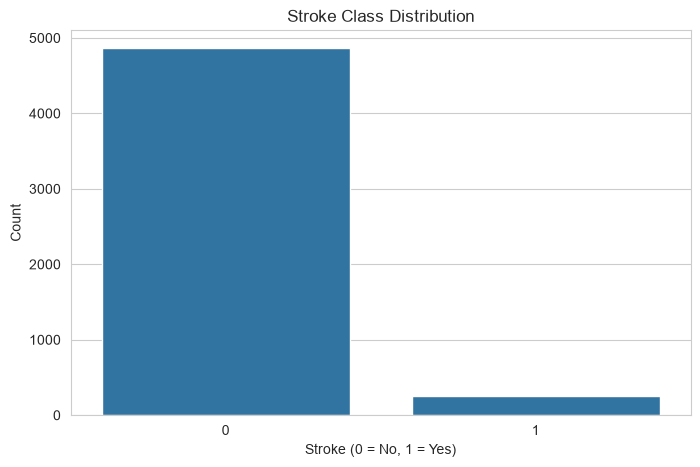

In [11]:
stroke_counts = df['stroke'].value_counts()
stroke_pct = df['stroke'].value_counts(normalize=True) * 100

print(stroke_counts)
print(stroke_pct)

sns.countplot(data=df, x='stroke')
plt.title('Stroke Class Distribution')
plt.xlabel('Stroke (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.savefig('../outputs/figures/stroke_class_distribution.png', bbox_inches='tight')
plt.show()


**Finding:** The dataset is heavily imbalanced — only about 5% of patients 
had a stroke. This is realistic for a rare medical event, but it means:
- Accuracy alone will be a misleading metric later for KNN classification
- Precision, recall, and F1-score (or ROC-AUC) will matter more
- Clustering is unlikely to produce a clean "stroke cluster" since stroke 
  cases are sparse and spread across the feature space — worth checking 
  explicitly in the clustering notebook rather than assuming it will work


## 4. Univariate Analysis

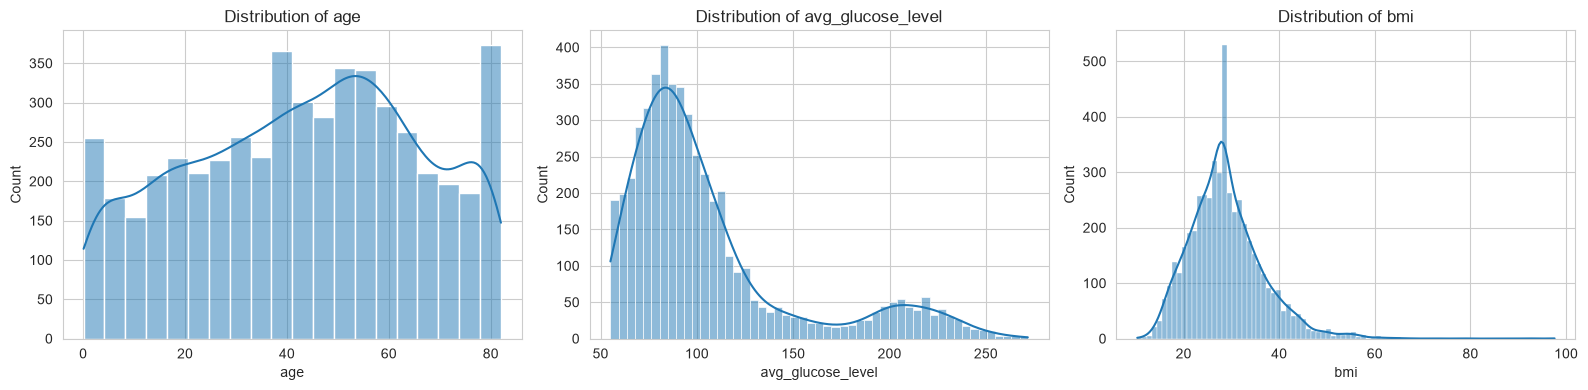

In [12]:
numeric_cols = ['age', 'avg_glucose_level', 'bmi']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('../outputs/figures/numeric_distributions.png', bbox_inches='tight')
plt.show()


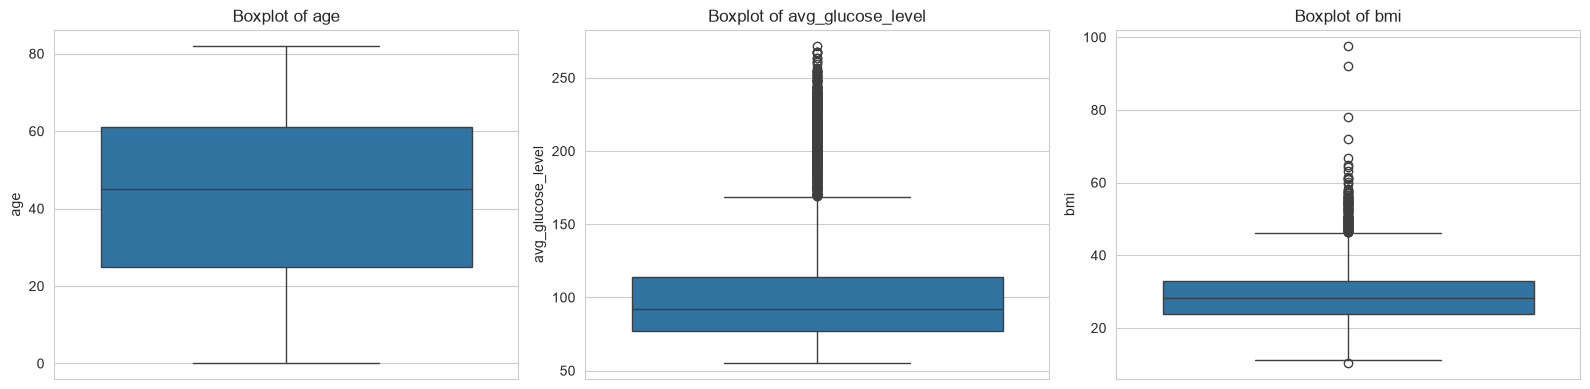

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.savefig('../outputs/figures/numeric_boxplots.png', bbox_inches='tight')
plt.show()


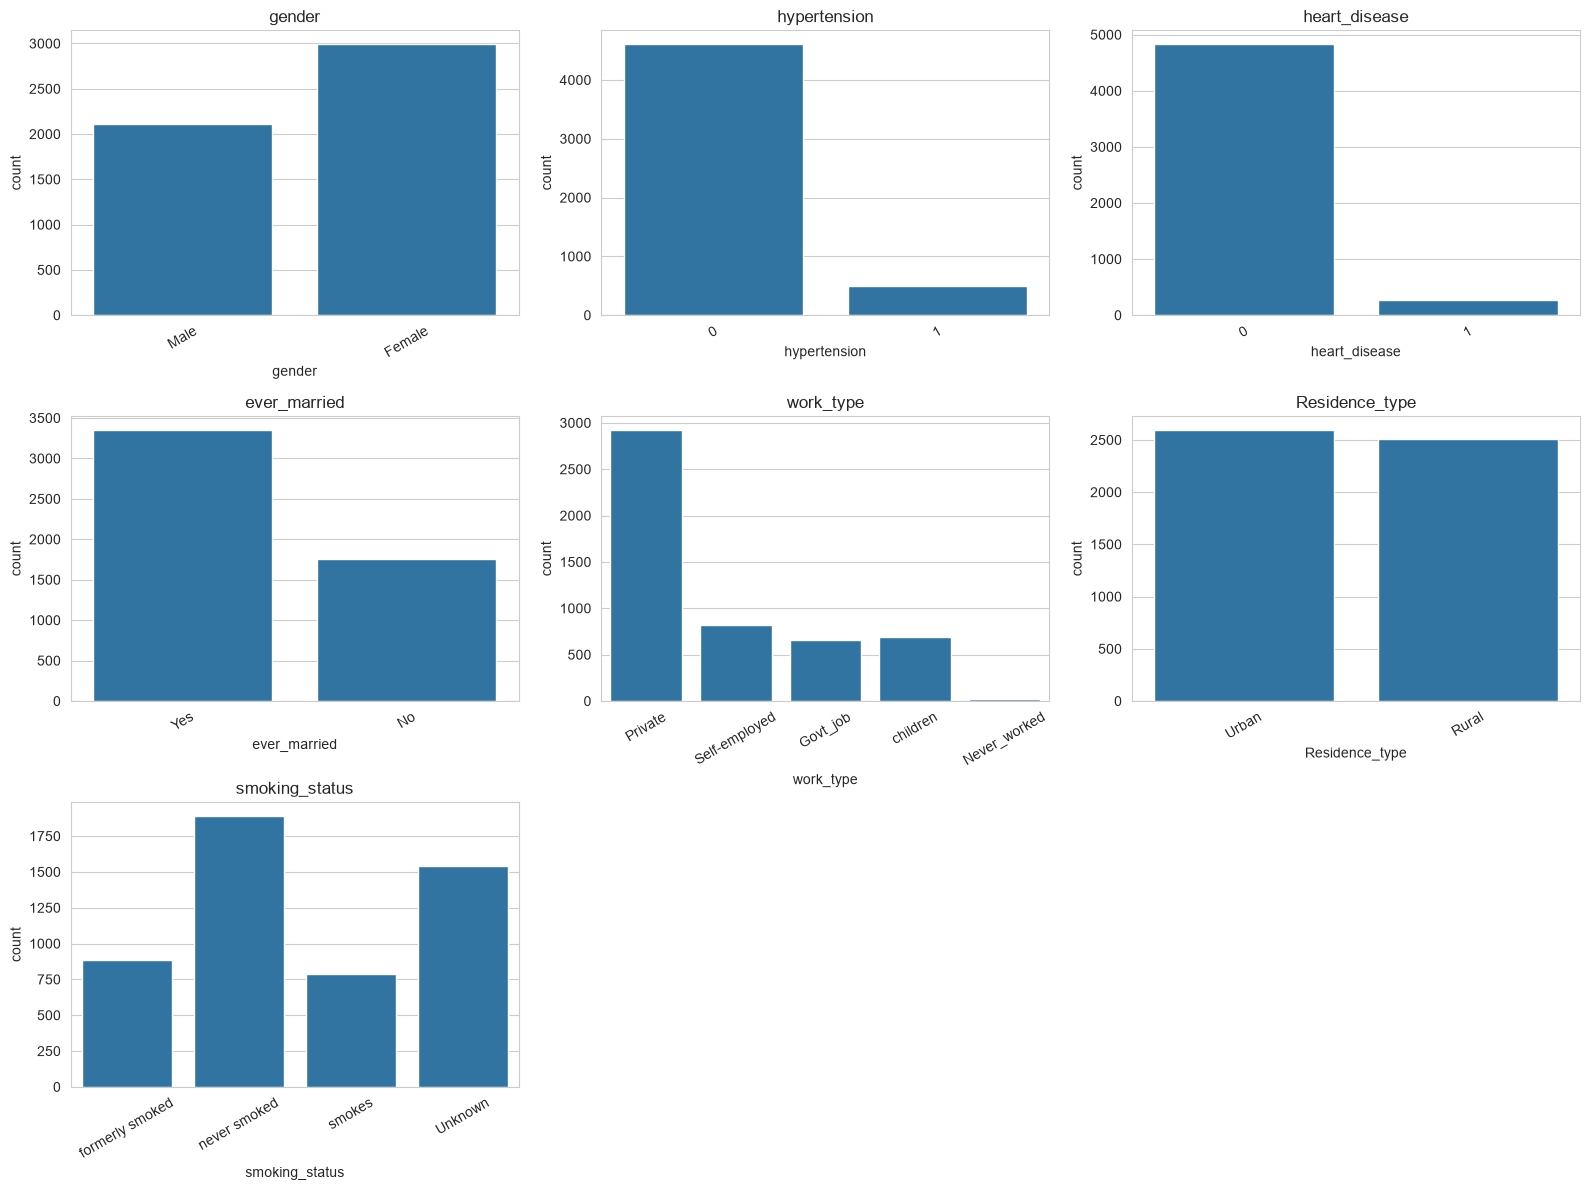

In [14]:
categorical_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married',
                    'work_type', 'Residence_type', 'smoking_status']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for ax, col in zip(axes, categorical_cols):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
# Hide unused subplot(s)
for ax in axes[len(categorical_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.savefig('../outputs/figures/categorical_distributions.png', bbox_inches='tight')
plt.show()


**Findings:**
- `age` spans the full adult (and child) range, roughly uniform after childhood
- `avg_glucose_level` and `bmi` are right-skewed, with some high outliers 
  worth keeping in mind for distance-based models later (KNN/K-means are 
  sensitive to scale and outliers — will need `StandardScaler` before modeling)
- Most patients are not hypertensive and don't have heart disease (expected, 
  matches the low base rate of these conditions)
- `work_type` and `smoking_status` both have meaningfully sized categories 
  worth keeping as-is rather than merging


## 5. Bivariate Analysis — Features vs. Stroke

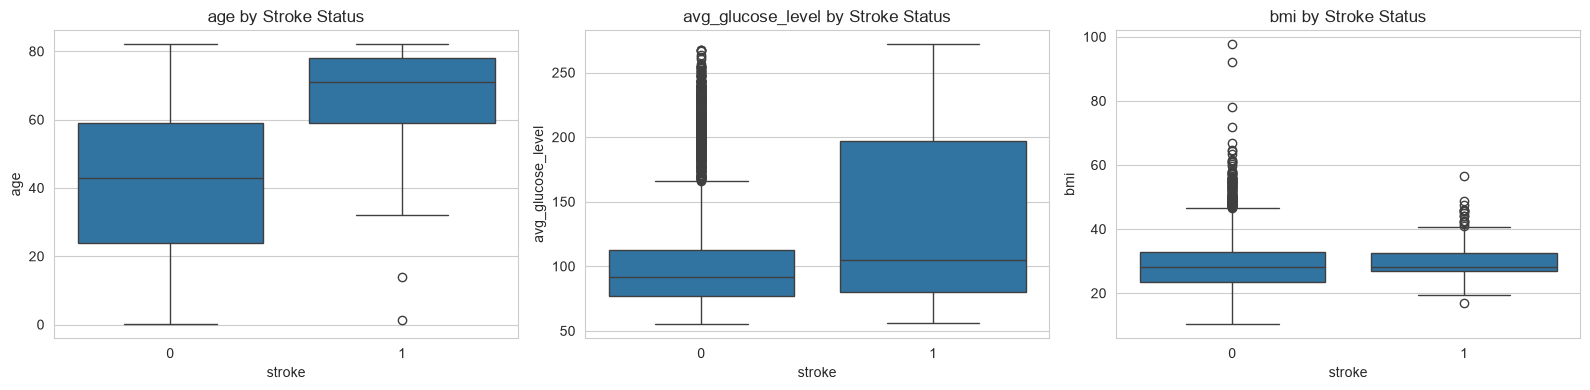

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x='stroke', y=col, ax=ax)
    ax.set_title(f'{col} by Stroke Status')
plt.tight_layout()
plt.savefig('../outputs/figures/numeric_vs_stroke.png', bbox_inches='tight')
plt.show()


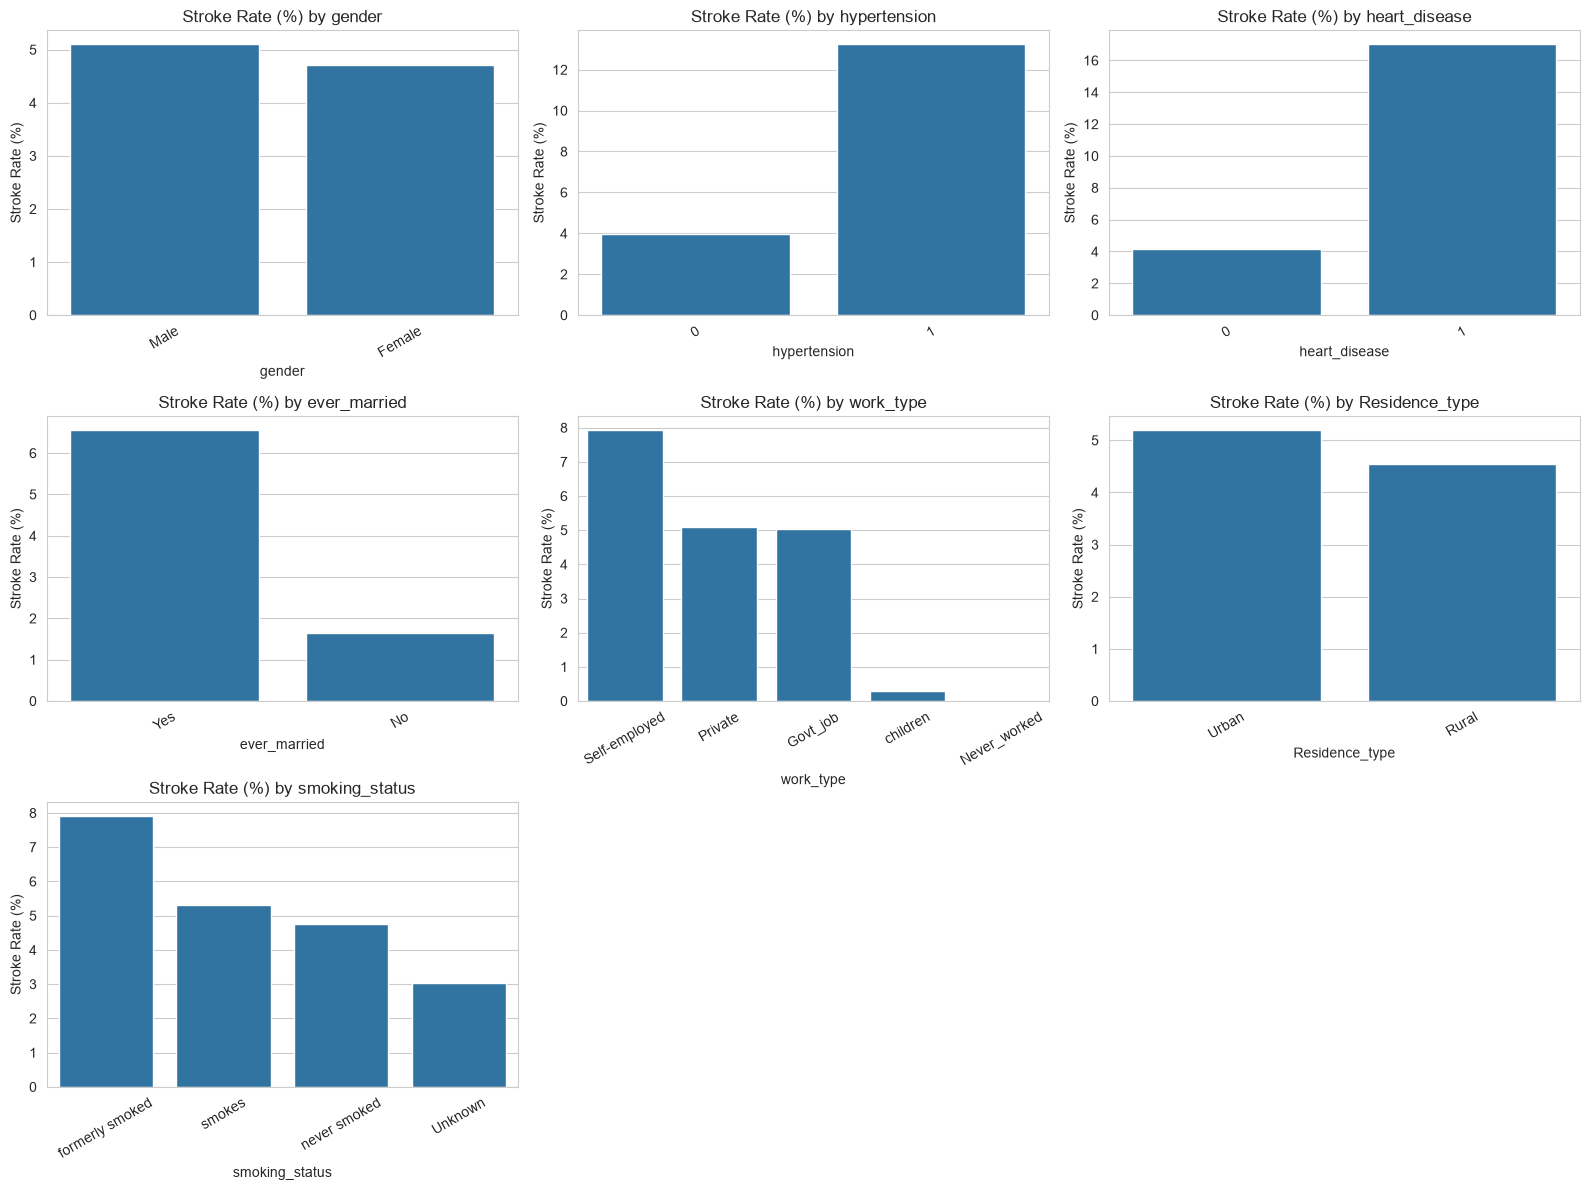

In [16]:
def stroke_rate_by(col):
    rate = df.groupby(col)['stroke'].mean().sort_values(ascending=False) * 100
    return rate

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for ax, col in zip(axes, categorical_cols):
    rate = stroke_rate_by(col)
    sns.barplot(x=rate.index, y=rate.values, ax=ax)
    ax.set_title(f'Stroke Rate (%) by {col}')
    ax.set_ylabel('Stroke Rate (%)')
    ax.tick_params(axis='x', rotation=30)
for ax in axes[len(categorical_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.savefig('../outputs/figures/stroke_rate_by_category.png', bbox_inches='tight')
plt.show()


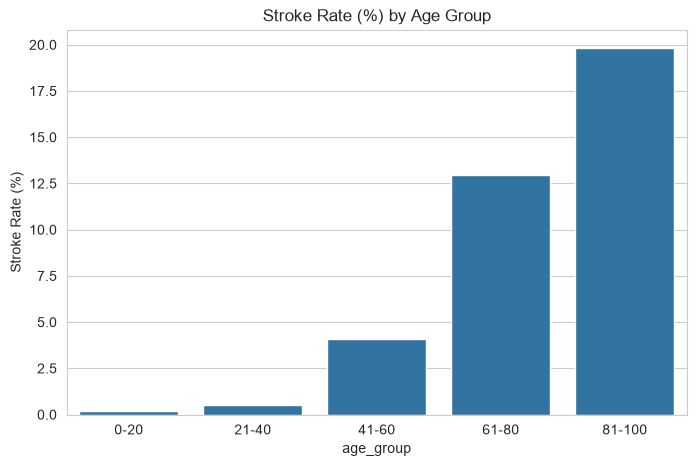

In [17]:
# Age is one of the strongest known stroke risk factors — bin it for a clearer view
df['age_group'] = pd.cut(df['age'], bins=[0, 20, 40, 60, 80, 100],
                          labels=['0-20', '21-40', '41-60', '61-80', '81-100'])

age_stroke_rate = df.groupby('age_group', observed=True)['stroke'].mean() * 100

sns.barplot(x=age_stroke_rate.index, y=age_stroke_rate.values)
plt.title('Stroke Rate (%) by Age Group')
plt.ylabel('Stroke Rate (%)')
plt.savefig('../outputs/figures/stroke_rate_by_age_group.png', bbox_inches='tight')
plt.show()


**Findings:**
- Stroke patients skew notably older — median age is much higher among 
  stroke cases than non-stroke cases
- Stroke rate rises sharply in the 60+ age groups, consistent with known 
  clinical risk patterns
- Patients with hypertension and heart disease show a visibly higher stroke 
  rate than those without
- `avg_glucose_level` tends to be higher among stroke patients, though with 
  overlap between groups
- `work_type` shows some variation (e.g., self-employed patients — who skew 
  older — show a higher stroke rate), but this is likely confounded by age 
  rather than an independent effect


## 6. Correlation Analysis

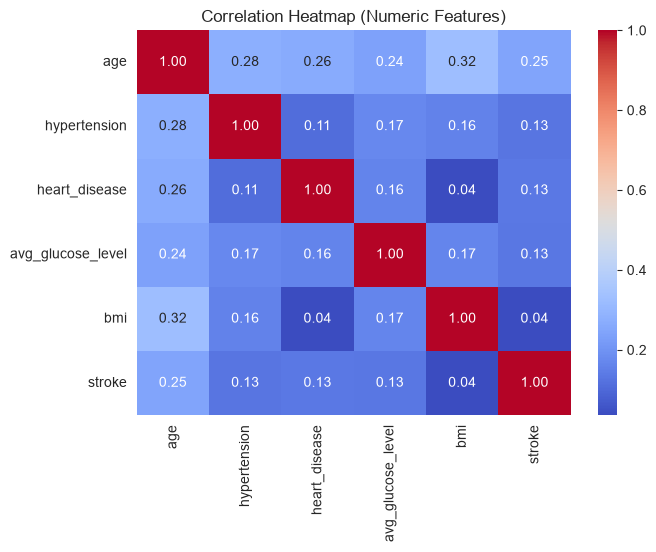

In [18]:
corr_cols = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']

plt.figure(figsize=(7, 5))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numeric Features)')
plt.savefig('../outputs/figures/correlation_heatmap.png', bbox_inches='tight')
plt.show()


**Finding:** `age` shows the strongest correlation with `stroke` among 
numeric features, followed by `hypertension`, `heart_disease`, and 
`avg_glucose_level`. None of the correlations are very strong individually — 
which is expected for a real medical outcome — suggesting a model will need 
to combine multiple features rather than rely on any single strong predictor.


## 7. Save Cleaned Data for Modeling Notebooks

In [19]:
df.to_csv('../data/processed/cleaned_stroke_data.csv', index=False)
print("Saved cleaned dataset:", df.shape)


Saved cleaned dataset: (5109, 12)


## 8. Key Findings Summary

- The dataset is **heavily imbalanced** (~5% stroke cases) — later modeling 
  needs to account for this explicitly (class weighting, resampling, and 
  precision/recall-based evaluation rather than accuracy).
- **Age is the strongest single driver** of stroke risk in this data, with 
  risk rising sharply after 60.
- **Hypertension, heart disease, and elevated glucose levels** are 
  secondary but consistent risk indicators.
- `bmi` and `avg_glucose_level` are right-skewed with outliers — will need 
  scaling (e.g., `StandardScaler`) before KNN or K-means, since both are 
  distance-based methods.
- No single feature cleanly separates stroke from non-stroke cases — this 
  sets a realistic expectation for the clustering notebook: clusters will 
  likely reflect general risk-factor groupings (e.g., older + hypertensive) 
  rather than a clean "stroke vs. no-stroke" split.

**Next notebook:** `02_classification_knn.ipynb` — building and evaluating 
a KNN classifier on this cleaned data, with proper handling of scaling and 
class imbalance.
